# FORESIGHT — Exploratory Data Analysis

## Demand & Inventory Intelligence

This notebook analyzes the processed FORESIGHT datasets to identify:
- demand trend and seasonality
- category and SKU demand patterns
- top-moving and slow-moving products
- dead-stock candidates
- promotion-associated demand
- inventory coverage and risk screening
- actionable business insights

**Important:** Inventory risk labels in this notebook are exploratory screening rules.
The final forecast-based risk scoring belongs to D4.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
# Resolve the project root robustly for a notebook located in notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "processed"

print("Project root:", PROJECT_ROOT)
print("Processed data:", DATA_DIR)

Project root: c:\Users\shiva\OneDrive\Desktop\Company\foresight-demand-inventory-intelligence
Processed data: c:\Users\shiva\OneDrive\Desktop\Company\foresight-demand-inventory-intelligence\data\processed


In [3]:
# Load the four processed datasets
sales = pd.read_csv(
    DATA_DIR / "sales_daily.csv",
    parse_dates=["date"]
)

sku = pd.read_csv(
    DATA_DIR / "sku_master.csv",
    parse_dates=["launch_date"]
)

calendar = pd.read_csv(
    DATA_DIR / "calendar.csv",
    parse_dates=["date"]
)

inventory = pd.read_csv(
    DATA_DIR / "inventory_snapshots.csv",
    parse_dates=["date"]
)

print("Sales:", sales.shape)
print("SKU Master:", sku.shape)
print("Calendar:", calendar.shape)
print("Inventory:", inventory.shape)

Sales: (4143430, 6)
SKU Master: (5000, 6)
Calendar: (1461, 6)
Inventory: (24872, 6)


## 1. Data Quality Summary

The processed datasets are the outputs of the reproducible D1 pipeline.
The D2 notebook verifies the basic handoff before analysis.

In [4]:
quality_summary = pd.DataFrame({
    "dataset": [
        "sales_daily",
        "sku_master",
        "calendar",
        "inventory_snapshots"
    ],
    "rows": [
        len(sales),
        len(sku),
        len(calendar),
        len(inventory)
    ],
    "columns": [
        sales.shape[1],
        sku.shape[1],
        calendar.shape[1],
        inventory.shape[1]
    ],
    "missing_values": [
        int(sales.isna().sum().sum()),
        int(sku.isna().sum().sum()),
        int(calendar.isna().sum().sum()),
        int(inventory.isna().sum().sum())
    ]
})

quality_summary

,dataset,rows,columns,missing_values
0,sales_daily,4143430,6,0
1,sku_master,5000,6,0
2,calendar,1461,6,0
3,inventory_snapshots,24872,6,0


In [5]:
# Basic key integrity checks
print("Sales SKUs missing from master:",
      len(set(sales["sku_id"]) - set(sku["sku_id"])))

print("Inventory SKUs missing from master:",
      len(set(inventory["sku_id"]) - set(sku["sku_id"])))

print("Sales dates missing from calendar:",
      len(set(sales["date"]) - set(calendar["date"])))

Sales SKUs missing from master: 0
Inventory SKUs missing from master: 0
Sales dates missing from calendar: 0


## 2. Demand Trend

In [6]:
sales["year"] = sales["date"].dt.year
sales["month"] = sales["date"].dt.month
sales["month_name"] = sales["date"].dt.month_name()
sales["week"] = sales["date"].dt.isocalendar().week.astype(int)
sales["day_of_week"] = sales["date"].dt.day_name()
sales["quarter"] = sales["date"].dt.quarter

daily_demand = (
    sales.groupby("date", as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum")
    )
)

daily_demand.head()

,date,units_sold,revenue
0,2022-01-01,9539,5803048.93
1,2022-01-02,9645,5933508.44
2,2022-01-03,9696,6041608.01
3,2022-01-04,9755,5847850.64
4,2022-01-05,9322,5832333.56


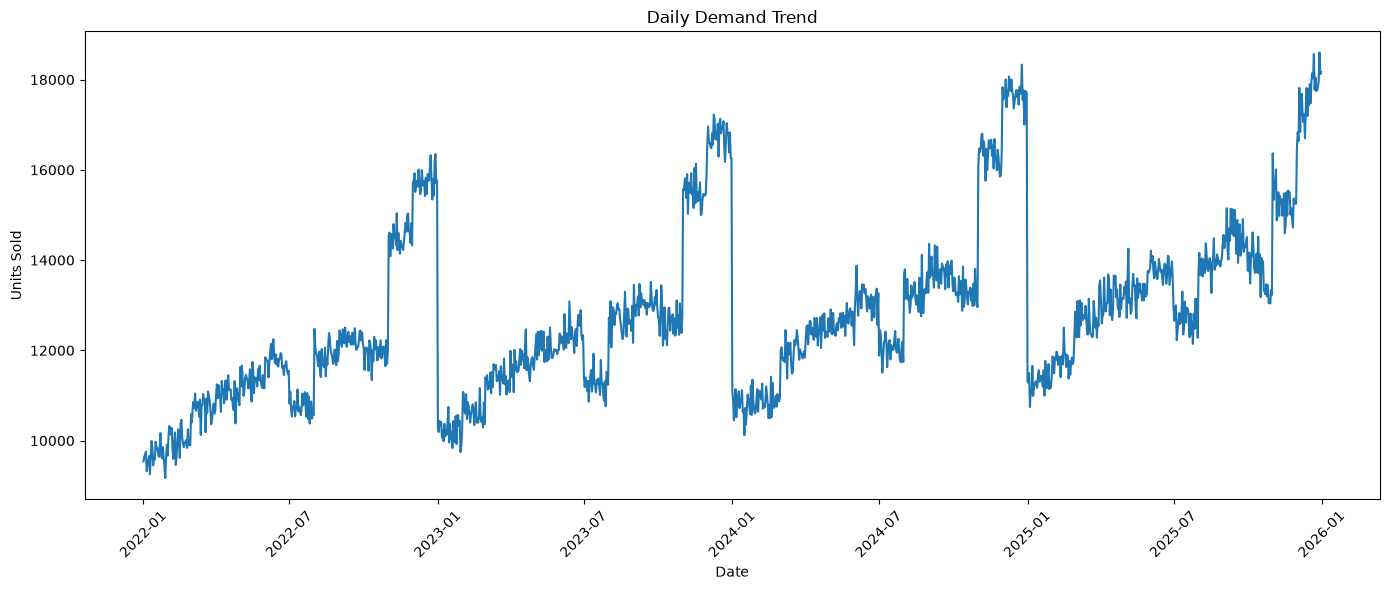

In [7]:
plt.figure(figsize=(14, 6))
plt.plot(daily_demand["date"], daily_demand["units_sold"])
plt.title("Daily Demand Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
monthly_demand = (
    sales.groupby(["year", "month"], as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum")
    )
)

monthly_demand["period"] = pd.to_datetime(
    monthly_demand["year"].astype(str)
    + "-"
    + monthly_demand["month"].astype(str)
    + "-01"
)

monthly_demand

,year,month,units_sold,revenue,period
0,2022,1,299649,1.820395e+08,2022-01-01
1,2022,2,279983,1.710435e+08,2022-02-01
2,2022,3,332417,2.042833e+08,2022-03-01
3,2022,4,330560,2.050013e+08,2022-04-01
4,2022,5,351452,2.063285e+08,2022-05-01
5,2022,6,352922,1.630977e+08,2022-06-01
6,2022,7,333342,2.053246e+08,2022-07-01
7,2022,8,367973,2.256207e+08,2022-08-01
8,2022,9,367848,2.233422e+08,2022-09-01
9,2022,10,370513,2.307381e+08,2022-10-01


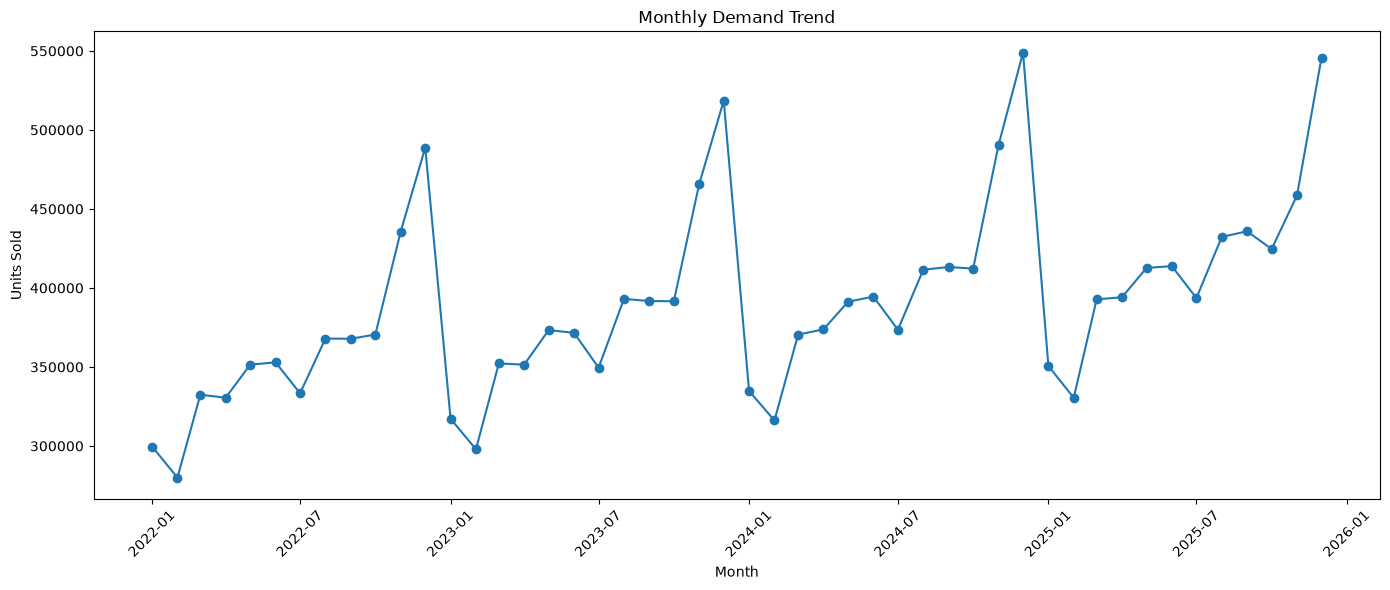

In [9]:
plt.figure(figsize=(14, 6))
plt.plot(
    monthly_demand["period"],
    monthly_demand["units_sold"],
    marker="o"
)
plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

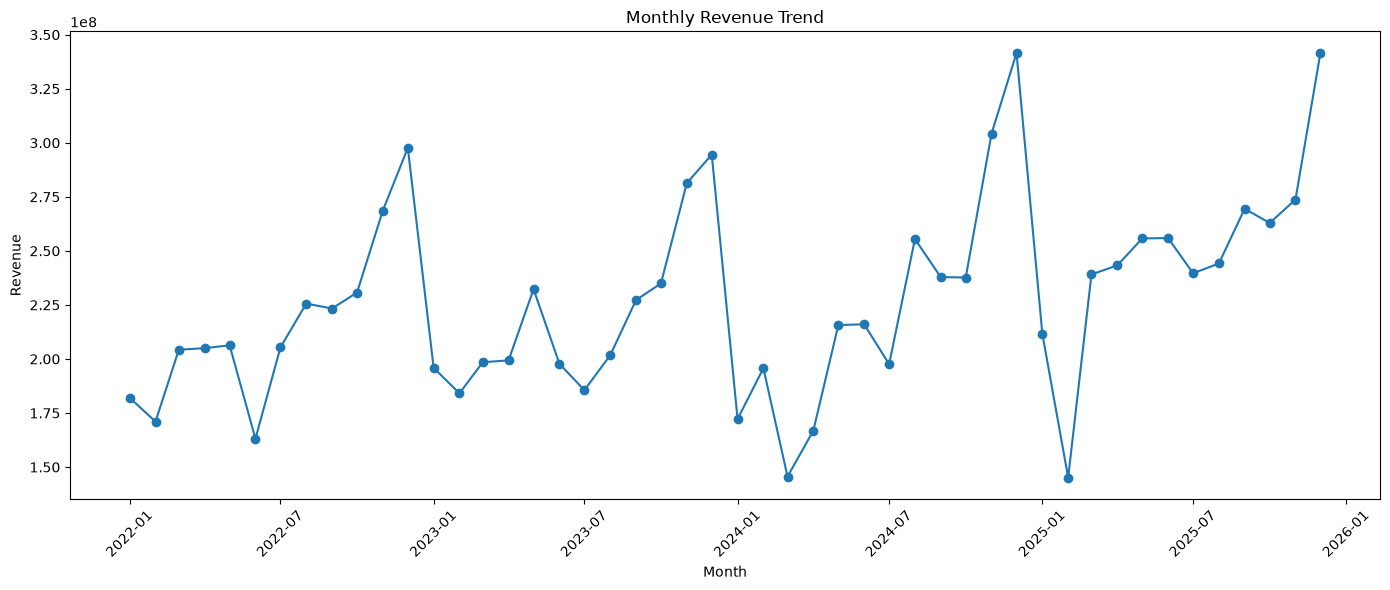

In [10]:
plt.figure(figsize=(14, 6))
plt.plot(
    monthly_demand["period"],
    monthly_demand["revenue"],
    marker="o"
)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Seasonality

In [11]:
weekday_demand = (
    sales.groupby("day_of_week", as_index=False)
    .agg(
        avg_units_sold=("units_sold", "mean"),
        total_units_sold=("units_sold", "sum")
    )
)

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_demand["day_of_week"] = pd.Categorical(
    weekday_demand["day_of_week"],
    categories=weekday_order,
    ordered=True
)

weekday_demand = weekday_demand.sort_values("day_of_week")
weekday_demand

,day_of_week,avg_units_sold,total_units_sold
1,Monday,4.514161,2675444
5,Tuesday,4.511460,2680105
6,Wednesday,4.518510,2676119
4,Thursday,4.509076,2656842
0,Friday,4.512988,2663805
2,Saturday,4.515033,2679112
3,Sunday,4.512464,2669479


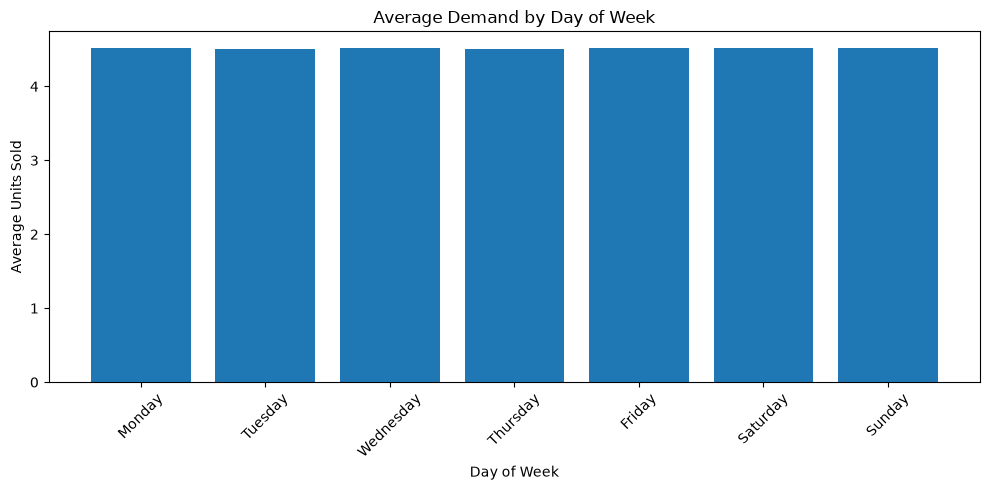

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(
    weekday_demand["day_of_week"],
    weekday_demand["avg_units_sold"]
)
plt.title("Average Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
monthly_seasonality = (
    sales.groupby("month", as_index=False)
    .agg(
        avg_units_sold=("units_sold", "mean"),
        total_units_sold=("units_sold", "sum")
    )
)

monthly_seasonality

,month,avg_units_sold,total_units_sold
0,1,4.135530,1302295
1,2,4.176886,1224500
2,3,4.328649,1447920
3,4,4.387597,1449934
4,5,4.440326,1528720
5,6,4.498459,1532841
6,7,4.325197,1449940
7,8,4.526913,1604827
8,9,4.600826,1608688
9,10,4.506535,1598932


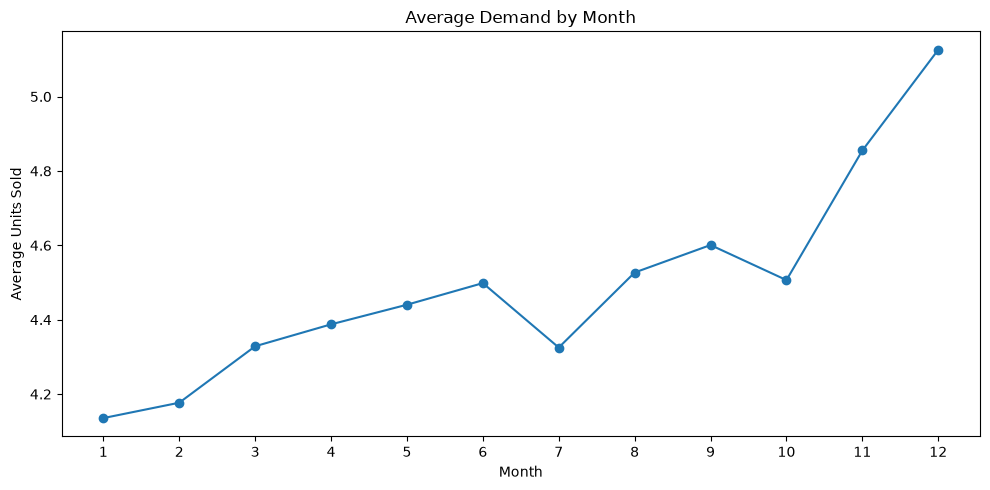

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_seasonality["month"],
    monthly_seasonality["avg_units_sold"],
    marker="o"
)
plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

## 4. Category Analysis

In [15]:
sales_sku = sales.merge(
    sku[["sku_id", "category", "subcategory"]],
    on="sku_id",
    how="left",
    validate="many_to_one"
)

print("Sales rows without category:",
      sales_sku["category"].isna().sum())

category_demand = (
    sales_sku.groupby("category", as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum")
    )
    .sort_values("units_sold", ascending=False)
)

category_demand

Sales rows without category: 0


,category,units_sold,revenue
9,Personal Care,2704996,1.618258e+09
11,Stationery & Office,1742469,3.093953e+08
2,Dairy & Bakery,1718591,3.511117e+08
8,Home Care,1553994,4.220981e+08
4,Frozen Foods,1548577,8.136173e+08
5,Grocery,1491246,3.493301e+08
1,Beverages,1417063,1.808762e+08
7,Home & Kitchen,1402335,1.578784e+09
3,Electronics & Accessories,1378400,2.328292e+09
10,Snacks & Confectionery,1263790,1.328065e+08


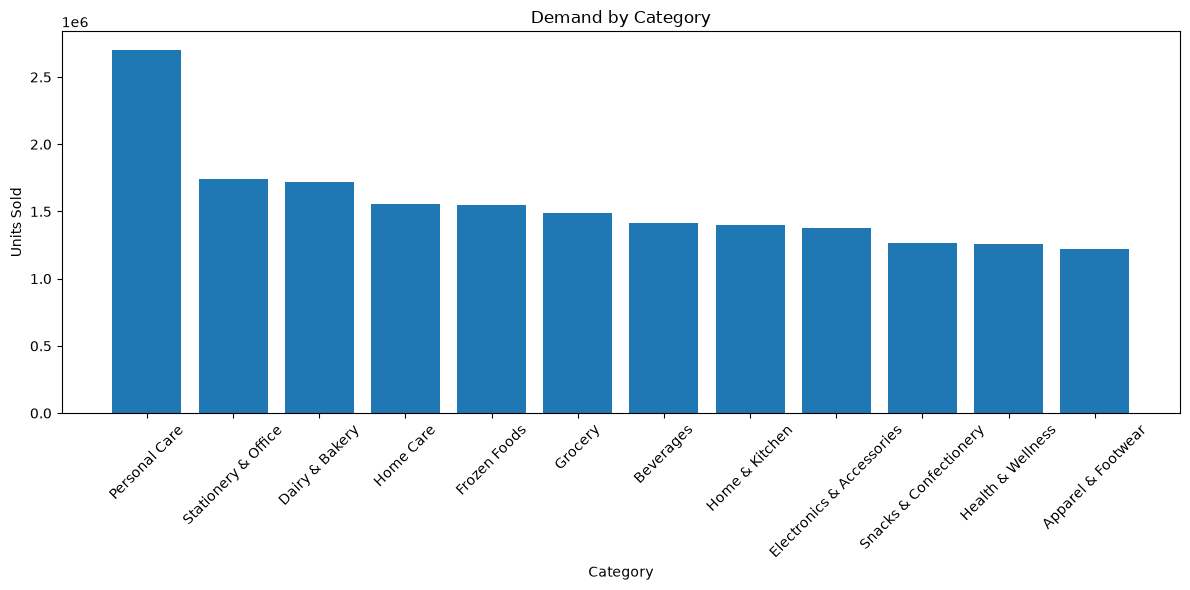

In [16]:
plt.figure(figsize=(12, 6))
plt.bar(
    category_demand["category"],
    category_demand["units_sold"]
)
plt.title("Demand by Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Top-Moving SKUs and Demand Concentration

In [17]:
sku_sales_stats = (
    sales.groupby("sku_id", as_index=False)
    .agg(
        total_units=("units_sold", "sum"),
        total_revenue=("revenue", "sum"),
        selling_days=("date", "nunique")
    )
    .sort_values("total_units", ascending=False)
)

top_skus = (
    sku_sales_stats.head(20)
    .merge(
        sku[["sku_id", "category", "subcategory"]],
        on="sku_id",
        how="left",
        validate="one_to_one"
    )
)

top_skus

,sku_id,total_units,total_revenue,selling_days,category,subcategory
0,SKU04321,1186104,1.069036e+09,1461,Personal Care,Hair Care
1,SKU04596,283431,8.881353e+07,1461,Dairy & Bakery,Eggs
2,SKU03727,166840,2.599450e+08,1461,Electronics & Accessories,Mobile Accessories
3,SKU04154,131174,4.259141e+07,1461,Grocery,Spices & Seasoning
4,SKU00953,114297,2.935862e+07,1461,Stationery & Office,Writing Instruments
5,SKU00190,101824,1.388548e+07,1461,Stationery & Office,Writing Instruments
6,SKU02141,98951,4.392344e+07,1461,Personal Care,Bath & Body
7,SKU00994,95420,5.351277e+07,1461,Home & Kitchen,Home Decor
8,SKU03292,92494,1.409103e+07,1461,Grocery,Pulses & Lentils
9,SKU01775,80414,1.545274e+07,1461,Personal Care,Hair Care


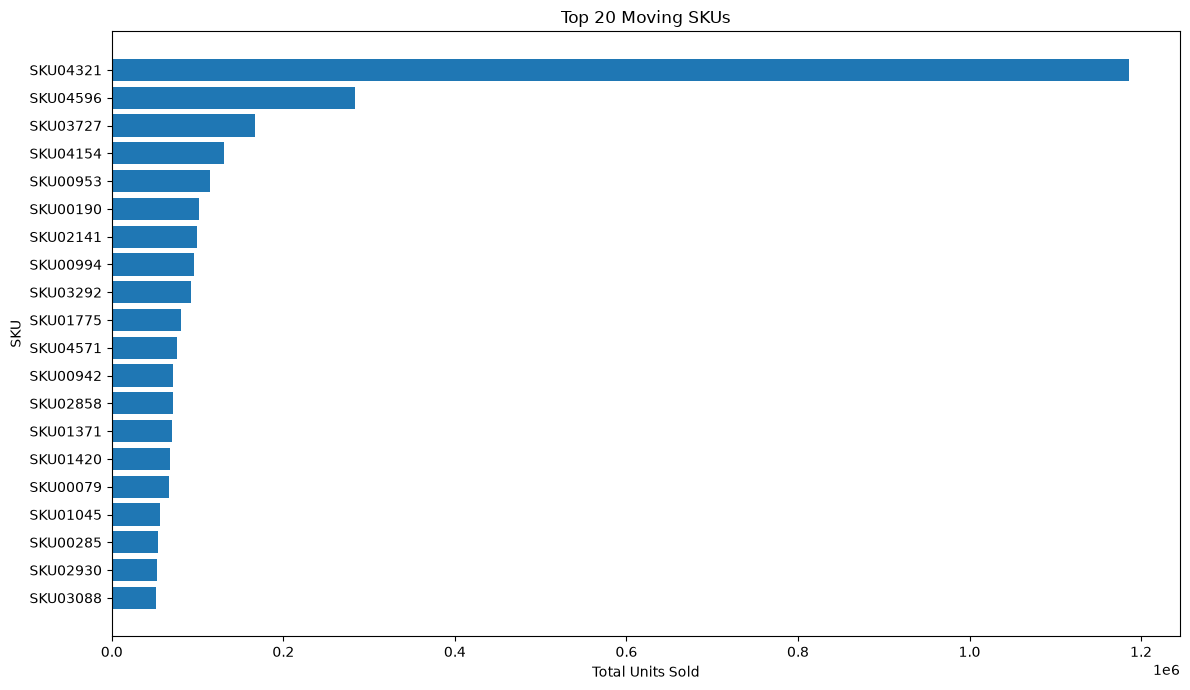

In [18]:
plt.figure(figsize=(12, 7))
plt.barh(
    top_skus["sku_id"],
    top_skus["total_units"]
)
plt.title("Top 20 Moving SKUs")
plt.xlabel("Total Units Sold")
plt.ylabel("SKU")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:
total_units = sku_sales_stats["total_units"].sum()

concentration = []
for n in [1, 5, 10, 20, 50, 100]:
    share = sku_sales_stats.head(n)["total_units"].sum() / total_units * 100
    concentration.append({
        "sku_group": f"Top {n}",
        "units_share_pct": share
    })

sku_concentration = pd.DataFrame(concentration)
sku_concentration

,sku_group,units_share_pct
0,Top 1,6.342495
1,Top 5,10.062860
2,Top 10,12.571311
3,Top 20,15.989455
4,Top 50,21.227913
5,Top 100,26.741164


In [20]:
top_sku_id = sku_sales_stats.iloc[0]["sku_id"]
top_sku_share = (
    sku_sales_stats.iloc[0]["total_units"] /
    total_units * 100
)

print("Top SKU:", top_sku_id)
print(f"Top SKU share of total units: {top_sku_share:.2f}%")

Top SKU: SKU04321
Top SKU share of total units: 6.34%


## 6. Slow-Moving and Dead-Stock Candidates

For slow-moving analysis, average demand is calculated over the **full
calendar period**, so days with zero sales are not silently excluded.

Slow-moving and dead-stock labels are screening categories, not confirmed
business classifications.

In [21]:
start_date = sales["date"].min()
end_date = sales["date"].max()
total_calendar_days = (end_date - start_date).days + 1

sku_total_demand = (
    sales.groupby("sku_id", as_index=False)
    .agg(
        total_units=("units_sold", "sum"),
        total_revenue=("revenue", "sum"),
        selling_days=("date", "nunique")
    )
)

sku_total_demand["avg_daily_demand"] = (
    sku_total_demand["total_units"] /
    total_calendar_days
)

sku_total_demand["sales_frequency_pct"] = (
    sku_total_demand["selling_days"] /
    total_calendar_days * 100
)

print("Analysis start:", start_date)
print("Analysis end:", end_date)
print("Calendar days:", total_calendar_days)

Analysis start: 2022-01-01 00:00:00
Analysis end: 2025-12-31 00:00:00
Calendar days: 1461


In [22]:
low_demand_threshold = sku_total_demand["avg_daily_demand"].quantile(0.10)

low_demand_skus = (
    sku_total_demand[
        sku_total_demand["avg_daily_demand"] <= low_demand_threshold
    ]
    .sort_values("avg_daily_demand")
)

print("Bottom 10% low-demand SKUs:", len(low_demand_skus))
low_demand_skus.head(20)

Bottom 10% low-demand SKUs: 501


,sku_id,total_units,total_revenue,selling_days,avg_daily_demand,sales_frequency_pct
1862,SKU01863,1105,58456.07,510,0.756331,34.907598
4692,SKU04693,1130,235099.96,496,0.773443,33.949350
2661,SKU02662,1133,138312.69,508,0.775496,34.770705
3967,SKU03968,1136,127559.06,513,0.777550,35.112936
2569,SKU02570,1136,191580.86,510,0.777550,34.907598
748,SKU00749,1139,158795.09,520,0.779603,35.592060
4855,SKU04856,1143,262165.64,507,0.782341,34.702259
3822,SKU03823,1145,57700.14,500,0.783710,34.223135
2575,SKU02576,1146,687783.43,503,0.784394,34.428474
2876,SKU02877,1148,100763.59,509,0.785763,34.839151


### Dead-stock screening rule

A dead-stock candidate is screened as a SKU with:
- very low average calendar-day demand (bottom 5%)
- low sales frequency (<20% of calendar days)
- positive inventory on hand

This is a candidate screen only; the extracts do not provide shelf-life,
clearance, or lifecycle status.

In [23]:
# Inventory summary used for D2 screening
inventory_summary = (
    inventory.groupby("sku_id", as_index=False)
    .agg(
        avg_on_hand=("on_hand_units", "mean"),
        max_on_hand=("on_hand_units", "max"),
        avg_on_order=("on_order_units", "mean"),
        lead_time_days=("lead_time_days", "mean"),
        reorder_point=("reorder_point", "mean")
    )
)

inventory_risk = inventory_summary.merge(
    sku_total_demand,
    on="sku_id",
    how="left",
    validate="one_to_one"
)

inventory_risk["days_of_stock"] = np.where(
    inventory_risk["avg_daily_demand"] > 0,
    inventory_risk["avg_on_hand"] /
    inventory_risk["avg_daily_demand"],
    np.inf
)

inventory_risk.head()

,sku_id,avg_on_hand,max_on_hand,avg_on_order,lead_time_days,reorder_point,total_units,total_revenue,selling_days,avg_daily_demand,sales_frequency_pct,days_of_stock
0,SKU00001,215.0,215,0.000000,7.0,100.000000,4771,3624393.59,1207,3.265572,82.614648,65.838399
1,SKU00002,0.0,0,83.263158,7.0,83.263158,38167,2518160.08,1461,26.123888,100.000000,0.000000
2,SKU00003,103.5,174,5.750000,7.0,62.500000,1325,189058.31,570,0.906913,39.014374,114.123396
3,SKU00004,148.0,148,0.000000,7.0,99.000000,2534,556401.40,901,1.734428,61.670089,85.330702
4,SKU00005,82.2,150,16.400000,7.0,56.800000,2292,300920.55,821,1.568789,56.194387,52.397120


In [24]:
dead_stock_candidates = inventory_risk[
    (inventory_risk["avg_daily_demand"] <=
     sku_total_demand["avg_daily_demand"].quantile(0.05))
    &
    (inventory_risk["sales_frequency_pct"] < 20)
    &
    (inventory_risk["avg_on_hand"] > 0)
].copy()

dead_stock_candidates = dead_stock_candidates.sort_values(
    ["avg_on_hand", "days_of_stock"],
    ascending=False
)

print("Dead-stock candidates:", len(dead_stock_candidates))

dead_stock_candidates[
    [
        "sku_id",
        "avg_daily_demand",
        "sales_frequency_pct",
        "avg_on_hand",
        "days_of_stock"
    ]
].head(20)

Dead-stock candidates: 0


,sku_id,avg_daily_demand,sales_frequency_pct,avg_on_hand,days_of_stock


## 7. Promotion Analysis

In [25]:
promotion_summary = (
    sales.groupby("promo_flag", as_index=False)
    .agg(
        total_units=("units_sold", "sum"),
        avg_units=("units_sold", "mean"),
        total_revenue=("revenue", "sum"),
        sku_days=("sku_id", "count")
    )
)

promotion_summary["promotion_status"] = (
    promotion_summary["promo_flag"]
    .map({0: "No Promotion", 1: "Promotion"})
)

promotion_summary

,promo_flag,total_units,avg_units,total_revenue,sku_days,promotion_status
0,0,14769588,4.534211,9.143638e+09,3257367,No Promotion
1,1,3931318,4.436838,1.741842e+09,886063,Promotion


In [26]:
promo_avg = sales.loc[
    sales["promo_flag"] == 1,
    "units_sold"
].mean()

non_promo_avg = sales.loc[
    sales["promo_flag"] == 0,
    "units_sold"
].mean()

promo_lift = (
    (promo_avg - non_promo_avg) /
    non_promo_avg * 100
)

print(f"Promotion average demand: {promo_avg:.4f}")
print(f"Non-promotion average demand: {non_promo_avg:.4f}")
print(f"Observed promotion lift: {promo_lift:.2f}%")

Promotion average demand: 4.4368
Non-promotion average demand: 4.5342
Observed promotion lift: -2.15%


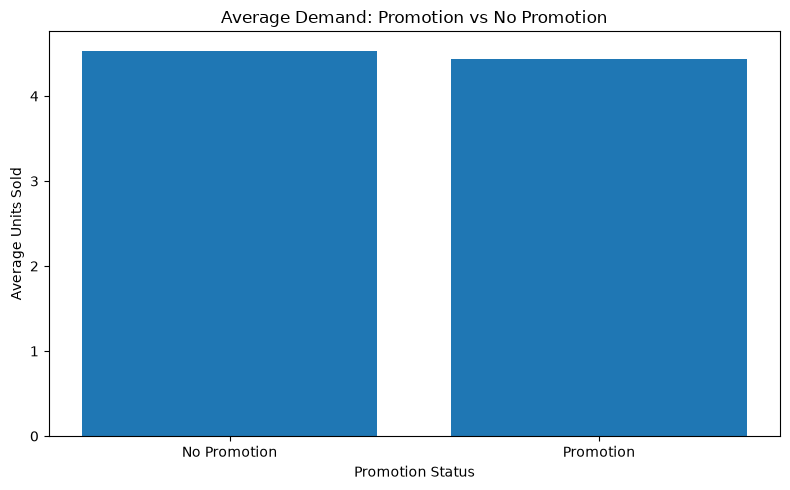

In [27]:
plt.figure(figsize=(8, 5))
plt.bar(
    promotion_summary["promotion_status"],
    promotion_summary["avg_units"]
)
plt.title("Average Demand: Promotion vs No Promotion")
plt.xlabel("Promotion Status")
plt.ylabel("Average Units Sold")
plt.tight_layout()
plt.show()

## 8. Inventory Risk Screening

These rules are intentionally labelled as **D2 screening rules**.

- Potential Stockout: days of stock below assumed lead time.
- Potential Overstock: more than 180 days of stock.
- Slow Moving: bottom 10% of calendar-day average demand with inventory.
- Normal: all remaining SKUs.

The 7-day lead time and 180-day overstock threshold are project analysis
assumptions, not forecast-derived decisions.

In [28]:
def classify_inventory_risk(row):
    if (
        row["avg_daily_demand"] > 0
        and row["days_of_stock"] < row["lead_time_days"]
    ):
        return "Potential Stockout"

    if row["days_of_stock"] > 180:
        return "Potential Overstock"

    if (
        row["avg_daily_demand"] <= low_demand_threshold
        and row["avg_on_hand"] > 0
    ):
        return "Slow Moving"

    return "Normal"


inventory_risk["risk_category"] = inventory_risk.apply(
    classify_inventory_risk,
    axis=1
)

inventory_risk["risk_category"].value_counts()

risk_category
Normal                 3492
Potential Stockout      862
Potential Overstock     601
Slow Moving              45
Name: count, dtype: int64

In [29]:
risk_summary = (
    inventory_risk
    .groupby("risk_category", as_index=False)
    .agg(
        sku_count=("sku_id", "nunique"),
        avg_inventory=("avg_on_hand", "mean"),
        avg_daily_demand=("avg_daily_demand", "mean"),
        avg_days_of_stock=("days_of_stock", "mean")
    )
)

risk_summary["sku_share_pct"] = (
    risk_summary["sku_count"] /
    risk_summary["sku_count"].sum() * 100
)

risk_summary.sort_values("sku_count", ascending=False)

,risk_category,sku_count,avg_inventory,avg_daily_demand,avg_days_of_stock,sku_share_pct
0,Normal,3492,93.155884,1.861312,61.755243,69.84
2,Potential Stockout,862,2.602412,6.643147,0.699313,17.24
1,Potential Overstock,601,287.054837,0.888117,327.102225,12.02
3,Slow Moving,45,74.344444,0.893771,83.179707,0.90


In [30]:
potential_overstock = (
    inventory_risk[
        (inventory_risk["avg_daily_demand"] <= low_demand_threshold)
        & (inventory_risk["avg_on_hand"] > 0)
    ]
    .sort_values("days_of_stock", ascending=False)
)

potential_overstock[
    [
        "sku_id",
        "avg_daily_demand",
        "sales_frequency_pct",
        "avg_on_hand",
        "days_of_stock",
        "reorder_point"
    ]
].head(20)

,sku_id,avg_daily_demand,sales_frequency_pct,avg_on_hand,days_of_stock,reorder_point
4474,SKU04475,0.869952,37.508556,423.478261,486.783430,93.347826
3114,SKU03115,0.837782,35.797399,404.423077,482.730486,83.500000
2545,SKU02546,0.850787,36.687201,409.166667,480.927192,86.277778
3280,SKU03281,0.874059,36.960986,408.440000,467.291182,87.240000
2252,SKU02253,0.852156,36.550308,393.739130,462.050498,84.608696
4249,SKU04250,0.802875,33.127995,365.695652,455.482820,79.782609
1804,SKU01805,0.859685,36.687201,386.782609,449.911936,82.434783
986,SKU00987,0.882957,37.097878,396.782609,449.379373,86.869565
4560,SKU04561,0.809719,35.660507,361.933333,446.986137,79.933333
3490,SKU03491,0.806297,36.413415,359.038462,445.293033,74.230769


In [31]:
potential_stockout = (
    inventory_risk[
        (inventory_risk["avg_daily_demand"] > 0)
        & (inventory_risk["avg_on_hand"] < inventory_risk["reorder_point"])
    ]
    .sort_values("avg_daily_demand", ascending=False)
)

potential_stockout[
    [
        "sku_id",
        "avg_daily_demand",
        "avg_on_hand",
        "reorder_point",
        "days_of_stock"
    ]
].head(20)

,sku_id,avg_daily_demand,avg_on_hand,reorder_point,days_of_stock
4320,SKU04321,811.843943,20.000000,78.923077,0.024635
4595,SKU04596,193.997947,0.000000,86.500000,0.000000
3726,SKU03727,114.195756,5.666667,66.000000,0.049622
4153,SKU04154,89.783710,16.350000,73.550000,0.182104
952,SKU00953,78.232033,0.000000,52.714286,0.000000
189,SKU00190,69.694730,0.000000,65.727273,0.000000
2140,SKU02141,67.728268,13.000000,71.437500,0.191943
993,SKU00994,65.311431,0.000000,70.388889,0.000000
3291,SKU03292,63.308693,0.000000,79.176471,0.000000
1774,SKU01775,55.040383,1.809524,63.428571,0.032876


# 9. Key Business Insights

### 1. Inventory imbalance
The D2 screening identifies both potential stockout and potential
overstock conditions. These groups should not be managed with a single
inventory policy.

### 2. Replenishment priority
Potential stockout SKUs have very low inventory coverage relative to
their observed demand and should receive priority in replenishment review.

### 3. Excess-inventory opportunity
Potential overstock candidates have substantially more inventory coverage
than their observed demand requires. Replenishment quantities and
inventory-reduction opportunities should be reviewed.

### 4. Demand concentration
The top 100 SKUs account for 26.74% of total units in this dataset.
Demand is therefore distributed across a broad SKU portfolio, requiring
scalable SKU-level forecasting.

### 5. Promotion effectiveness
Promotion-associated SKU-days show a -2.15% observed average-demand lift
in this dataset. This is an observational association, not evidence of
causality. Promotion effects should be evaluated by SKU/category and
incorporated carefully into forecasting.

# 10. D2 Conclusion

The EDA identifies clear demand trend and seasonal patterns, a broadly
distributed SKU demand portfolio, promotion-associated demand differences,
and material inventory imbalance.

The strongest operational signals are potential stockout exposure for
high-demand SKUs and potential overstock exposure for low-demand SKUs.

These findings motivate the next stage: weekly SKU-level demand forecasting
with a seasonal-naive baseline and rolling-origin backtesting.